In [5]:
import pandas as pd
import seaborn as sns
#import matplotlib.pyplot as plt
import numpy as np
import urllib.request
from pprint import pprint
#from html_table_parser.parser import HTMLTableParser
from yahooquery import Ticker
import plotly.graph_objects as go
pd.options.display.float_format = '{:,}'.format
import datetime as dt
from datetime import datetime
from sklearn.model_selection import cross_val_score,RepeatedKFold,RepeatedKFold,train_test_split
#import yfinance as yf
import math
from sklearn.linear_model import LogisticRegression
from sklearn import linear_model
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,r2_score,mean_squared_error
#from fredapi import Fred
from pandas_datareader import data as pdr

pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Collection

In [6]:
#inflation
inflation = pdr.get_data_fred('CPIAUCSL',start="1900-01-01",timeout=60).pct_change(periods=12) * 100
inflation = inflation.rename(columns={'CPIAUCSL': 'inflation_rt'})
#employment - non farming
employment_nonfarm = pdr.get_data_fred('PAYEMS',start="1900-01-01")#.pct_change(periods=12) * 100
employment_nonfarm = employment_nonfarm.rename(columns={'PAYEMS': 'employment_nonfarm'})
#employment - non farming
thirtyr = pdr.get_data_fred('MORTGAGE30US',timeout = 60,start="1900-01-01")#.pct_change(periods=12) * 100
thirtyr = thirtyr.rename(columns={'MORTGAGE30US': 'thirty_yr_rt'})
#employment - non farming
fifteenyr = pdr.get_data_fred('MORTGAGE15US',timeout = 60,start="1900-01-01")#.pct_change(periods=12) * 100
fifteenyr = fifteenyr.rename(columns={'MORTGAGE15US': 'fifteen_yr_rt'})
#employment - non farming
fedfunds = pdr.get_data_fred('FEDFUNDS',start="1900-01-01",timeout=60)#.pct_change(periods=12) * 100
fedfunds = fedfunds.rename(columns={'FEDFUNDS': 'fedfunds_rt'})
#interest - non farming
unemployment = pdr.get_data_fred('UNRATENSA',start="1900-01-01")#.pct_change(periods=12) * 100
unemployment = unemployment.rename(columns={'UNRATENSA': 'unemployment_rt'})
#employment - non farming
delinquencies = pdr.get_data_fred('DRCLACBS',start="1900-01-01",timeout=60)#.pct_change(periods=12) * 100
delinquencies = delinquencies.rename(columns={'DRCLACBS': 'delinquencies_rt'})
#employment - non farming
gdp = pdr.get_data_fred('GDPC1',start="1900-01-01",timeout=60)#.pct_change(periods=12) * 100
gdp = gdp.rename(columns={'GDPC1': 'gdp'})
#employment - non farming
tenyr_treasury = pdr.get_data_fred('GS10',start="1900-01-01",timeout=60)#.pct_change(periods=12) * 100
tenyr_treasury = tenyr_treasury.rename(columns={'GS10': '10yr_treasury_rt'})
#employment - non farming
twoyr_treasury = pdr.get_data_fred('GS2',start="1900-01-01")#.pct_change(periods=12) * 100
twoyr_treasury = twoyr_treasury.rename(columns={'GS2': '2yr_treasury_rt'})
#employment - non farming
labor_prod = pdr.get_data_fred('OPHNFB',start="1900-01-01")#.pct_change(periods=12) * 100
labor_prod = labor_prod.rename(columns={'OPHNFB': 'labor_productivity'})
#employment - non farming
unit_labor_cost = pdr.get_data_fred('ULCNFB',start="1900-01-01")#.pct_change(periods=12) * 100
unit_labor_cost = unit_labor_cost.rename(columns={'ULCNFB': 'unit_labor_cost'})
#employment - non farming
ind_prod = pdr.get_data_fred('INDPRO',start="1900-01-01")#.pct_change(periods=12) * 100
ind_prod = ind_prod.rename(columns={'INDPRO': 'industrial_production'})
#employment - non farming
retail_sales = pdr.get_data_fred('RSAFS',start="1900-01-01")#.pct_change(periods=12) * 100
retail_sales = retail_sales.rename(columns={'RSAFS': 'retail_sales'})
#employment - non farming
real_pi = pdr.get_data_fred('RPI',start="1900-01-01")#.pct_change(periods=12) * 100
real_pi = real_pi.rename(columns={'RPI': 'real_pi'})
#employment - non farming
wage_gr = pdr.get_data_fred('ECIWAG',start="1900-01-01")#.pct_change(periods=12) * 100
wage_gr = wage_gr.rename(columns={'ECIWAG': 'wage_growth'})

C:\Users\pbv01\AppData\Local\Temp\ipykernel_29172\3402007136.py:2: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  inflation = pdr.get_data_fred('CPIAUCSL',start="1900-01-01",timeout=60).pct_change(periods=12) * 100


In [12]:
print(inflation.index.min())
print(employment_nonfarm.index.min())
print(thirtyr.index.min())
print(fifteenyr.index.min())
print(fedfunds.index.min())
print(unemployment.index.min())
print(delinquencies.index.min())
print(gdp.index.min())
print(tenyr_treasury.index.min())
print(twoyr_treasury.index.min())
print(labor_prod.index.min())
print(unit_labor_cost.index.min())
print(ind_prod.index.min())
print(retail_sales.index.min())
print(real_pi.index.min())
print(wage_gr.index.min())

1947-01-01 00:00:00
1939-01-01 00:00:00
1971-04-02 00:00:00
1991-08-30 00:00:00
1954-07-01 00:00:00
1948-01-01 00:00:00
1987-01-01 00:00:00
1947-01-01 00:00:00
1953-04-01 00:00:00
1976-06-01 00:00:00
1947-01-01 00:00:00
1947-01-01 00:00:00
1919-01-01 00:00:00
1992-01-01 00:00:00
1959-01-01 00:00:00
2001-01-01 00:00:00


In [13]:
#dim date
start = "1900-01-01"
end = pd.Timestamp.today().normalize()  # or "today"
months = pd.date_range(start=start, end=end, freq="MS")  # month starts

dim_date = pd.DataFrame({"month": months})
dim_date["month_str"] = dim_date["month"].dt.strftime("%Y-%m")

# Cleaning

In [18]:
df = dim_date.merge(inflation, left_on='month',right_index=True,how='left')
df = df.merge(employment_nonfarm, left_on='month',right_index=True,how='left')
df = df.merge(thirtyr, left_on='month',right_index=True,how='left')
df = df.merge(fifteenyr, left_on='month',right_index=True,how='left')
df = df.merge(fedfunds, left_on='month',right_index=True,how='left')
df = df.merge(unemployment, left_on='month',right_index=True,how='left')
df = df.merge(delinquencies, left_on='month',right_index=True,how='left')
df = df.merge(gdp, left_on='month',right_index=True,how='left')
df = df.merge(tenyr_treasury, left_on='month',right_index=True,how='left')
df = df.merge(twoyr_treasury, left_on='month',right_index=True,how='left')
df = df.merge(labor_prod, left_on='month',right_index=True,how='left')
df = df.merge(unit_labor_cost, left_on='month',right_index=True,how='left')
df = df.merge(ind_prod, left_on='month',right_index=True,how='left')
df = df.merge(retail_sales, left_on='month',right_index=True,how='left')
df = df.merge(real_pi, left_on='month',right_index=True,how='left')
df = df.merge(wage_gr, left_on='month',right_index=True,how='left')

df = df.iloc[:-1,]

In [19]:
df.sort_values(by='month',ascending=True).head()

,month,month_str,inflation_rt,employment_nonfarm,thirty_yr_rt,fifteen_yr_rt,fedfunds_rt,unemployment_rt,delinquencies_rt,gdp,10yr_treasury_rt,2yr_treasury_rt,labor_productivity,unit_labor_cost,industrial_production,retail_sales,real_pi,ECIWAG
0,1900-01-01,1900-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1900-02-01,1900-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1900-03-01,1900-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1900-04-01,1900-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1900-05-01,1900-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
print(df.dtypes)
print(df.shape)

df.head()

month                    datetime64[ns]
month_str                        object
inflation_rt                    float64
employment_nonfarm              float64
thirty_yr_rt                    float64
fifteen_yr_rt                   float64
fedfunds_rt                     float64
unemployment_rt                 float64
delinquencies_rt                float64
gdp                             float64
10yr_treasury_rt                float64
2yr_treasury_rt                 float64
labor_productivity              float64
unit_labor_cost                 float64
industrial_production           float64
retail_sales                    float64
real_pi                         float64
ECIWAG                          float64
dtype: object
(1517, 18)


,month,month_str,inflation_rt,employment_nonfarm,thirty_yr_rt,fifteen_yr_rt,fedfunds_rt,unemployment_rt,delinquencies_rt,gdp,10yr_treasury_rt,2yr_treasury_rt,labor_productivity,unit_labor_cost,industrial_production,retail_sales,real_pi,ECIWAG
0,1900-01-01,1900-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1900-02-01,1900-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1900-03-01,1900-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1900-04-01,1900-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1900-05-01,1900-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
df_long = pd.melt(
    df, 
    id_vars=['month','month_str'], 
    value_vars=df.columns[2:],
    var_name='metric', 
    value_name='rate'
)

In [22]:
df_long.head()

,month,month_str,metric,rate
0,1900-01-01,1900-01,inflation_rt,NaN
1,1900-02-01,1900-02,inflation_rt,NaN
2,1900-03-01,1900-03,inflation_rt,NaN
3,1900-04-01,1900-04,inflation_rt,NaN
4,1900-05-01,1900-05,inflation_rt,NaN


# Visualization

In [23]:
df_long.metric.unique()

array(['inflation_rt', 'employment_nonfarm', 'thirty_yr_rt',
       'fifteen_yr_rt', 'fedfunds_rt', 'unemployment_rt',
       'delinquencies_rt', 'gdp', '10yr_treasury_rt', '2yr_treasury_rt',
       'labor_productivity', 'unit_labor_cost', 'industrial_production',
       'retail_sales', 'real_pi', 'ECIWAG'], dtype=object)

<Axes: xlabel='month', ylabel='rate'>

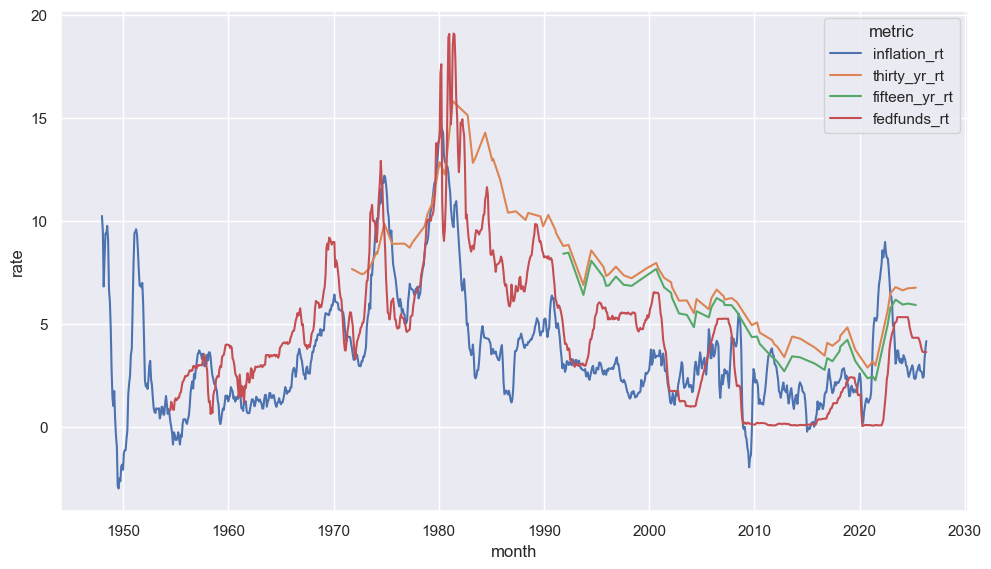

In [46]:
sns.set_theme(rc={'figure.figsize':(11.7,6.5)})

x = df_long.copy()
allowed_metrics = ['inflation_rt','fedfunds_rt','thirty_yr_rt','fifteen_yr_rt']
x = x[x['metric'].isin(allowed_metrics)]
sns.lineplot(x, x='month', y='rate', hue='metric')

<Axes: xlabel='month', ylabel='rate'>

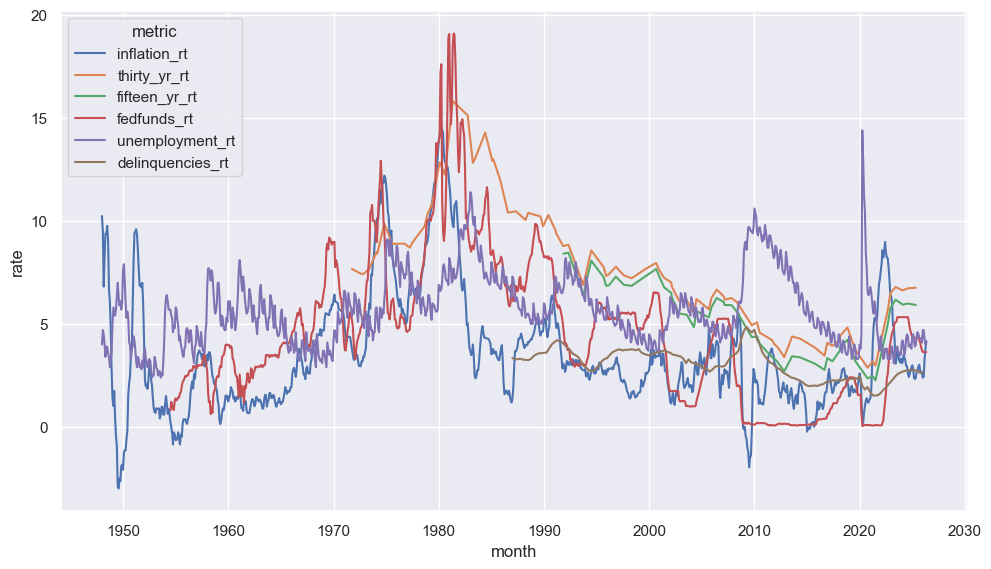

In [47]:
x = df_long.copy()
allowed_metrics = ['inflation_rt', 'thirty_yr_rt',
       'fedfunds_rt', 'unemployment_rt', 'delinquencies_rt','fifteen_yr_rt']
x = x[x['metric'].isin(allowed_metrics)]
sns.lineplot(x, x='month', y='rate', hue='metric')

<Axes: xlabel='month', ylabel='rate'>

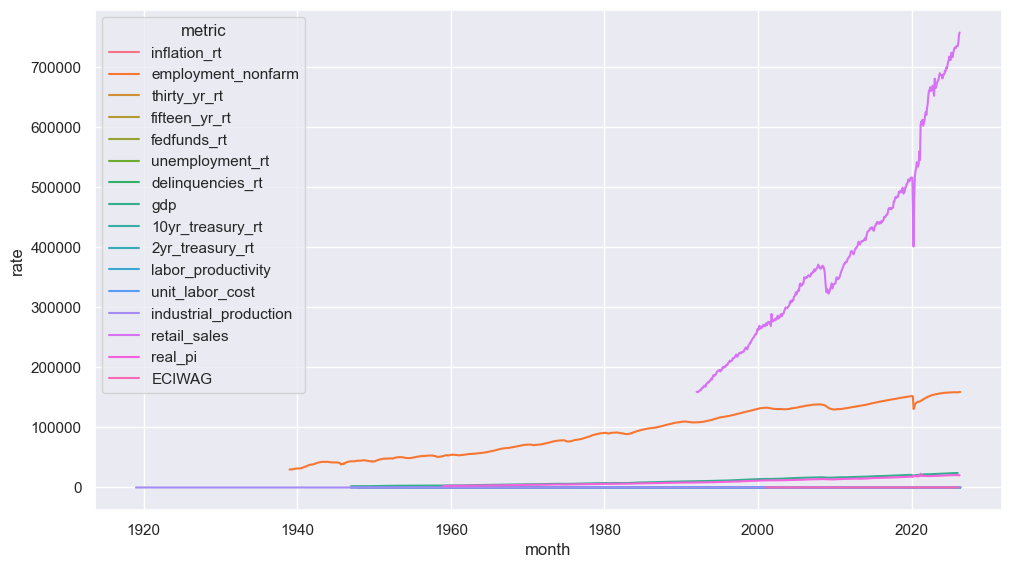

In [48]:
x = df_long.copy()
allowed_metrics = df.columns[2:]
x = x[x['metric'].isin(allowed_metrics)]
sns.lineplot(x, x='month', y='rate', hue='metric')

In [40]:
df.iloc[:,2:].head()

,inflation_rt,employment_nonfarm,thirty_yr_rt,fifteen_yr_rt,fedfunds_rt,unemployment_rt,delinquencies_rt,gdp,10yr_treasury_rt,2yr_treasury_rt,labor_productivity,unit_labor_cost,industrial_production,retail_sales,real_pi,ECIWAG
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: >

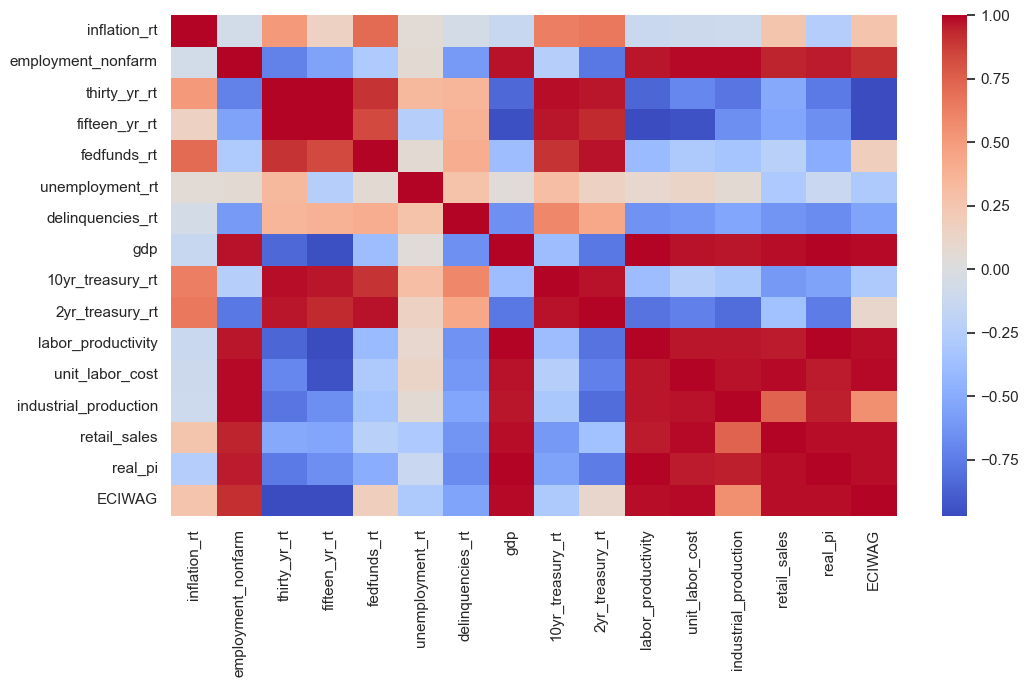

In [49]:
sns.heatmap(df.iloc[:,2:].corr(), cmap='coolwarm')

In [ ]:
employed = pd.DataFrame(fred.get_series('PAYEMS')).reset_index() #mortgage rates
employed['employed_difference'] = employed[0] - employed[0].shift(1)
employed['employed_difference'] = employed['employed_difference']*1000
employed.columns = ['date','employed','employed_difference']

In [19]:
delinquencies

,delinquencies_rt
DATE,
2021-07-01,1.520
2021-10-01,1.550
2022-01-01,1.650
2022-04-01,1.800
2022-07-01,1.920
2022-10-01,2.070
2023-01-01,2.220
2023-04-01,2.370
2023-07-01,2.520


In [37]:
fred.search('PAYEMS').head(5)

NameError: name 'fred' is not defined